# E-commerce Sales & Delivery Performance

## tl;dr
Delivered merchandise totals R$13.22m across 96,478 orders. Late delivery is 6.77% among orders with both dates; reviewed late orders average 2.27/5 versus 4.29/5 on time. Investigate RJ lanes using counts and rates; do not infer causality.

Full dataset run. Historical portfolio case study prepared with AI assistance; no operational intervention was implemented.

## Context & Methods
Audience: e-commerce operations. Unit: orders for delivery/reviews, item value for sales. SQL lives in `sql/`; Python runs queries, reconciles outputs, and plots.

### Key Assumptions
Read [methods](docs/methodology.md) for exclusions and denominator choices. Delivered orders only; item prices exclude freight. Missing delivery dates leave the rate denominator. Multiple reviews are averaged within each order. The final sales month may be incomplete.

## Data
Run `python download_data.py` once before this notebook. Source files remain in `data/raw/` and are not published. Download links, licensing, and provenance are in the [README](README.md). The following cell rebuilds results directly from the original files.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, SVG
from build_portfolio import build, charts
summary = build()
print(summary['validation'])

Done. Review results/data_quality.csv before interpreting results.


PASS: independent pandas totals, each month, category reconciliation, state denominators and review means


### Review aggregate evidence
Tables below are generated by the pipeline; they are not manually entered.

In [2]:
import pandas as pd
from IPython.display import display
table = pd.read_csv('results/03_delivery_reviews.csv')
display(table[['state', 'eligible_delivered_orders', 'late_orders', 'late_delivery_pct']].rename(columns={'eligible_delivered_orders': 'Eligible deliveries', 'late_orders': 'Late orders', 'late_delivery_pct': 'Late (%)'}).head(10))

,state,Eligible deliveries,Late orders,Late (%)
0,AL,397,85,21.41
1,MA,717,125,17.43
2,SE,335,51,15.22
3,PI,476,66,13.87
4,CE,1279,176,13.76
5,RR,41,5,12.20
6,BA,3256,396,12.16
7,RJ,12350,1495,12.11
8,PA,946,106,11.21
9,ES,1995,214,10.73


## Results
Figures are generated by the editable plotting functions in `build_portfolio.py`. Source result CSVs remain available for inspection.

In [3]:
figures = charts()
plt.close('all')

### Monthly Sales

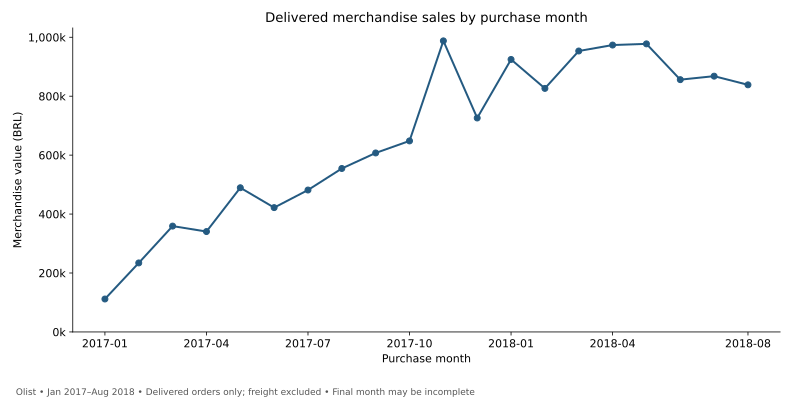

In [4]:
display(SVG(filename='charts/monthly_sales.svg'))

The displayed monthly peak is November 2017. Opening sparse months are omitted; final-month incompleteness prevents using the right edge as evidence of a downturn.

### Category Sales

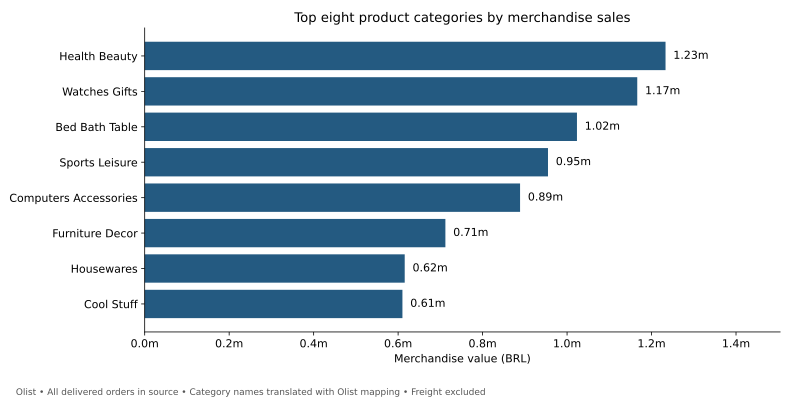

In [5]:
display(SVG(filename='charts/category_sales.svg'))

Health & Beauty leads the categories; the top five contribute 39.83% of merchandise value. Costs are unavailable, so this does not rank profit.

### Delivery States

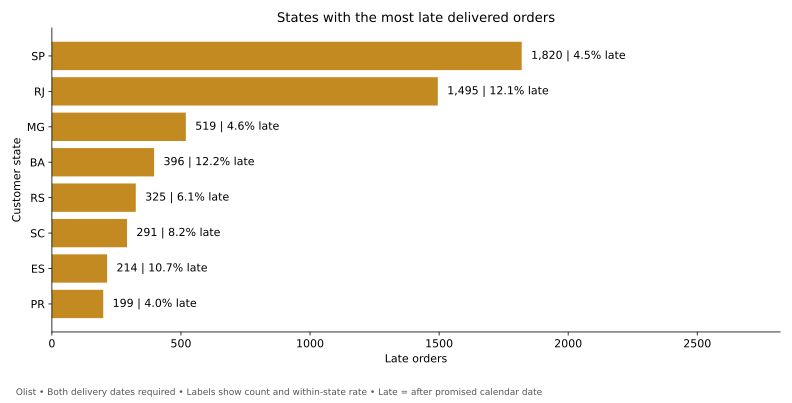

In [6]:
display(SVG(filename='charts/delivery_states.svg'))

RJ combines 1,495 late orders with a 12.11% late rate; SP has the highest count but a lower rate. This supports investigation rather than a causal diagnosis.

### Delivery Reviews

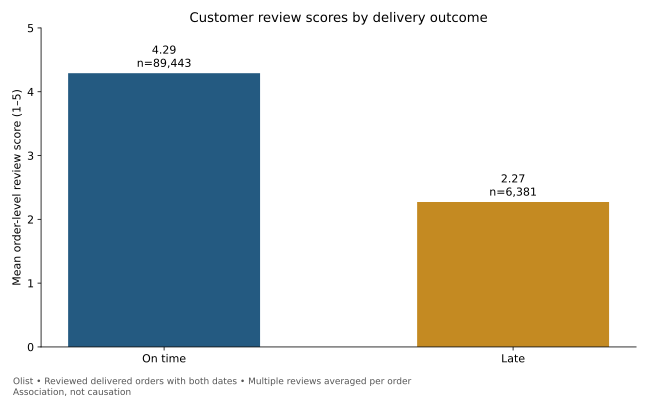

In [7]:
display(SVG(filename='charts/delivery_reviews.svg'))

Late orders have lower average review scores. Each reviewed order has equal weight after averaging its reviews; geography, seller mix, and timing can confound the association.

## Takeaways
Delivered merchandise totals R$13.22m across 96,478 orders. Late delivery is 6.77% among orders with both dates; reviewed late orders average 2.27/5 versus 4.29/5 on time. Investigate RJ lanes using counts and rates; do not infer causality.

Read the [findings and proposed actions](docs/findings.md) and [interview guide](docs/interview-guide.md). Key calculations reconcile in the build assertions. Descriptive findings do not establish campaign lift, causal delivery impact, or current market performance.